[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HSF-reco-and-software-triggers/Tracking-ML-Exa.TrkX/blob/master/Examples/TrackML_Quickstart/DM_colab_quickstart.ipynb)

# TrackML Quickstart

## Install Libraries

**Note: Before running notebook, ensure your runtime is set to GPU**

First, we just install a few libraries (this should take around 5 minutes and automatically restart the kernel), and load in the repository.

In [1]:
# !pip install -q condacolab
# import condacolab
# condacolab.install()

In [2]:
# !pip install seaborn bokeh 
# !conda install pandas scipy matplotlib cupy "cudatoolkit>=11.3" "pytorch>=1.10.2" "pytorch-lightning>=1.6" pyg faiss-gpu -c pytorch -c pyg -c conda-forge

In [3]:
# !git clone https://github.com/HSF-reco-and-software-triggers/Tracking-ML-Exa.TrkX.git
# %cd Tracking-ML-Exa.TrkX/Examples/TrackML_Quickstart

# Import libraries

In [4]:
import sys, os
sys.path.append("../../")
from Scripts import train_metric_learning, run_metric_learning_inference, train_gnn, run_gnn_inference, build_track_candidates, evaluate_candidates
from Scripts.utils.convenience_utils import get_example_data, plot_true_graph, get_training_metrics, plot_training_metrics, plot_neighbor_performance, plot_predicted_graph, plot_track_lengths, plot_edge_performance, plot_graph_sizes
import yaml

import warnings
warnings.filterwarnings("ignore")
CONFIG = 'pipeline_config_quirk.yaml'
# pipeline_config_quirk.yaml

Loading BokehJS ...

/home/rafia/miniconda3/envs/trackml-quickstart/lib/python3.12/site-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
/home/rafia/miniconda3/envs/trackml-quickstart/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading BokehJS ...

## Download Data

In [5]:
# %%capture
# !mkdir datasets
# !wget https://portal.nersc.gov/cfs/m3443/dtmurnane/TrackML_Example/trackml_quickstart_dataset.tar.gz -O datasets/trackml_quickstart_dataset.tar.gz

In [6]:
# %%capture
# !tar -xvf datasets/trackml_quickstart_dataset.tar.gz -C datasets;
# !rm datasets/trackml_quickstart_dataset.tar.gz

## TrackML Dataset

The TrackML dataset contains simulated indepedent proton-proton collision events, each generating hundreds of particles, each of which hits cells and layers of the detector layers multiple times. The detector records the spatial coordinates and other auxillary information of these hits which, if properly connected, form tracks associated with the parent particle and the collision event from which it originates. The challenge and goal of this project is to associate each and every hit to one single track with optimal purity and efficiency, whose precise definition will be given later.

Each entry in the particles data frame contains a unique identifier of the particle (particle_id), its charge (q), its initial position or vertex $(v_x, v_y, v_z)$, its initial momentum in GeV/c $(p_x, p_y, p_z)$ and its associated number of detector hits. 

Many particles do not leave behind any detector hits and obviously cannot be associated to any track. This is called "detector inefficiency". They are among "uninterested particles" and will be mostly filtered out by a simple momentum cut.

### Training data
Let us take a look at the data before training. In this example pipeline, we have preprocessed the TrackML data into a more convenient form. We calculated directional information and summary statistics from the charge deposited in each spacepoints, and append them to its cyclidrical coordinates. Let us load an example data file and inspect the content.

In [7]:
with open(CONFIG, 'r') as f:
    configs = yaml.load(f, Loader=yaml.FullLoader)

In [8]:
example_data_df, example_data_pyg = get_example_data(configs)
example_data_df.head()

,0,1,2
0,0.072500,-0.350956,0.000859
1,0.072032,-0.351867,0.000854
2,0.115152,-0.313051,0.001248
3,0.171399,-0.315628,0.001745
4,0.259040,-0.353420,0.002554


### Visualize tracks

A "true track" is defined as a set of sequential hits, all left by the same particle. Therefore a true edge is the edge formed by two sequential hits. Let's visualize a random set of 200 true tracks:

In [9]:
plot_true_graph_fig = plot_true_graph(example_data_pyg, num_tracks=200)

In [1]:
import importlib.util
import numpy as np
import inspect

spec = importlib.util.spec_from_file_location(
    "quirk_trajectory",
    "/home/rafia/trackml-quickstart-collab/Pipelines/TrackML_Example/"
    "LightningModules/Processing/utils/quirk_trajectory.py"
)

mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)
simulate = mod.simulate_quirk_pair_tracks

src = inspect.getsource(simulate)
print("Lorentz check:")
for line in src.split("\n"):
    if "lorentz_scale" in line:
        print(line)

test_configs = [
    (6.0, 3.0, 0.05, 1500),
    (6.0, 5.0, 0.05, 1500),
    (6.0, 8.0, 0.05, 1500),
    (10.0, 3.0, 0.05, 1500),
    (10.0, 5.0, 0.05, 1500),
    (10.0, 8.0, 0.05, 1500),
    (20.0, 3.0, 0.05, 1500),
    (20.0, 5.0, 0.05, 1500),
    (20.0, 8.0, 0.05, 1500),
]

print(f"{'pt':>6} {'pz':>5} {'kappa':>6} {'vel':>6} | {'r_max':>10} {'z_max':>8} | {'verdict':>12}")
print("-" * 75)

for pt, pz, kappa, vel in test_configs:
    result = simulate(
        event_id=0,
        n_steps=12000,
        t_max=8.0,
        b_field=2.0,
        charge=1.0,
        quirk_mass=1000.0,
        pair_pt=pt,
        pair_pz=pz,
        opening_angle=np.pi / 2,
        string_tension=kappa,
        velocity_scale=vel,
    )

    xyz1 = np.asarray(result["xyz_q"])
    xyz2 = np.asarray(result["xyz_aq"])

    r1 = np.sqrt(xyz1[:, 0]**2 + xyz1[:, 1]**2)
    r2 = np.sqrt(xyz2[:, 0]**2 + xyz2[:, 1]**2)

    r_max = float(max(r1.max(), r2.max()))
    z_max = float(max(abs(xyz1[:, 2]).max(), abs(xyz2[:, 2]).max()))
    finite = np.all(np.isfinite(xyz1)) and np.all(np.isfinite(xyz2))

    if not finite or r_max > 500000:
        verdict = "BLOWN UP"
    elif r_max < 100:
        verdict = "TOO SMALL"
    elif r_max < 200:
        verdict = "MARGINAL"
    elif r_max > 1100:
        verdict = "ESCAPES"
    else:
        verdict = "GOOD"

    print(f"{pt:>6.1f} {pz:>5.1f} {kappa:>6.2f} {vel:>6} | {r_max:>10.1f} {z_max:>8.1f} | {verdict:>12}")

Lorentz check:
        lorentz_scale = 0.003
        a1_lor = lorentz_scale * (+charge) * np.cross(v1s, b_vec) * inv_mass
        a2_lor = lorentz_scale * (-charge) * np.cross(v2s, b_vec) * inv_mass
    pt    pz  kappa    vel |      r_max    z_max |      verdict
---------------------------------------------------------------------------
   6.0   3.0   0.05   1500 |       49.9     18.0 |    TOO SMALL
   6.0   5.0   0.05   1500 |       49.9     30.0 |    TOO SMALL
   6.0   8.0   0.05   1500 |       49.9     48.0 |    TOO SMALL
  10.0   3.0   0.05   1500 |       83.8     18.0 |    TOO SMALL
  10.0   5.0   0.05   1500 |       83.8     30.0 |    TOO SMALL
  10.0   8.0   0.05   1500 |       83.8     48.0 |    TOO SMALL
  20.0   3.0   0.05   1500 |      168.7     18.0 |     MARGINAL
  20.0   5.0   0.05   1500 |      168.7     30.0 |     MARGINAL
  20.0   8.0   0.05   1500 |      168.7     48.0 |     MARGINAL


## new cell for event selection this is after this query ----

'''
First check

Plot only quirk and anti quirk hits for the same event.

That will tell you whether:
• there is a real short trajectory shape
or
• there are only a few points near the center

Second check

Zoom tightly around the origin.

For example, instead of the full [−1,1] detector scale, look only at a much smaller window around the quirk points.

Third check

Count how many quirk hits are actually in this event.

Because if this event has only a very small number of quirk hits, then the graph is behaving exactly as expected.

Fourth check

Inspect another projection too:
• x z
• r z
• or just quirk only edges

Sometimes the quirk is not obvious in x y, but becomes more visible in another view.
'''




In [ ]:
# pick quirk-rich event from current trainset
best_i, best_q = -1, -1
for i, ev in enumerate(metric_learning_model.trainset):
    if hasattr(ev, "source_label"):
        q = int((ev.source_label > 0).sum())
        if q > best_q:
            best_i, best_q = i, q

ev = metric_learning_model.trainset[best_i]
print("best_i:", best_i, "quirk_hits:", best_q)


best_i: 27 quirk_hits: 823


## below are the new plots..

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# assumes ev has ev.x (N, >=3) and ev.source_label
x = ev.x[:, 0].detach().cpu().numpy()
y = ev.x[:, 1].detach().cpu().numpy()
z = ev.x[:, 2].detach().cpu().numpy()
src = ev.source_label.detach().cpu().numpy()  # 0=SM, 1=Quirk, 2=Anti-Quirk

qmask = (src == 1) | (src == 2)
q = (src == 1)
aq = (src == 2)

print("SM:", int((src == 0).sum()))
print("Quirk:", int(q.sum()))
print("Anti-Quirk:", int(aq.sum()))
print("Total:", int(src.size))


SM: 1510
Quirk: 472
Anti-Quirk: 351
Total: 2333


In [ ]:
import matplotlib
import matplotlib.pyplot as plt

print("Current backend:", matplotlib.get_backend())

# Force notebook rendering
%matplotlib inline
matplotlib.rcParams["figure.dpi"] = 120

# Reset any stale state
plt.close("all")


Current backend: Agg


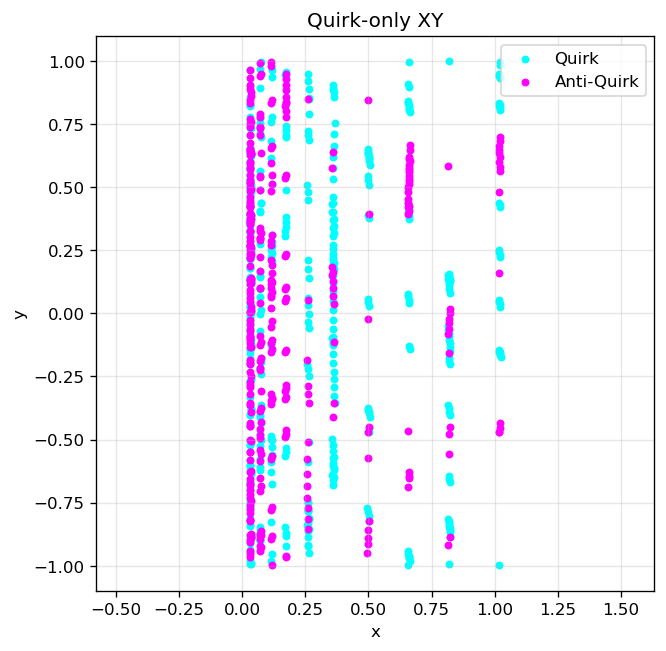

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(x[q], y[q], s=14, c="cyan", label="Quirk")
plt.scatter(x[aq], y[aq], s=14, c="magenta", label="Anti-Quirk")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.title("Quirk-only XY")
plt.axis("equal"); plt.grid(alpha=0.3)
plt.show()


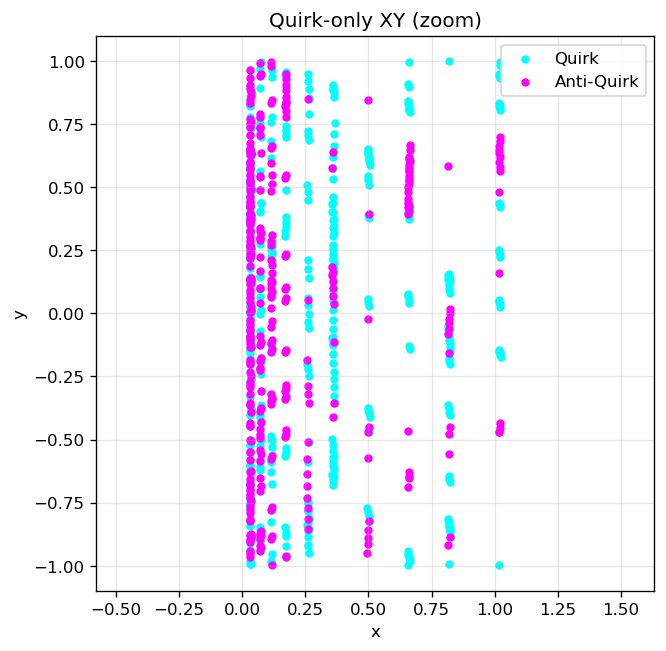

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(x[q], y[q], s=16, c="cyan", label="Quirk")
plt.scatter(x[aq], y[aq], s=16, c="magenta", label="Anti-Quirk")
plt.xlim(-0.15, 0.15)
plt.ylim(-0.15, 0.15)
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.title("Quirk-only XY (zoom)")
plt.axis("equal"); plt.grid(alpha=0.3)
plt.show()


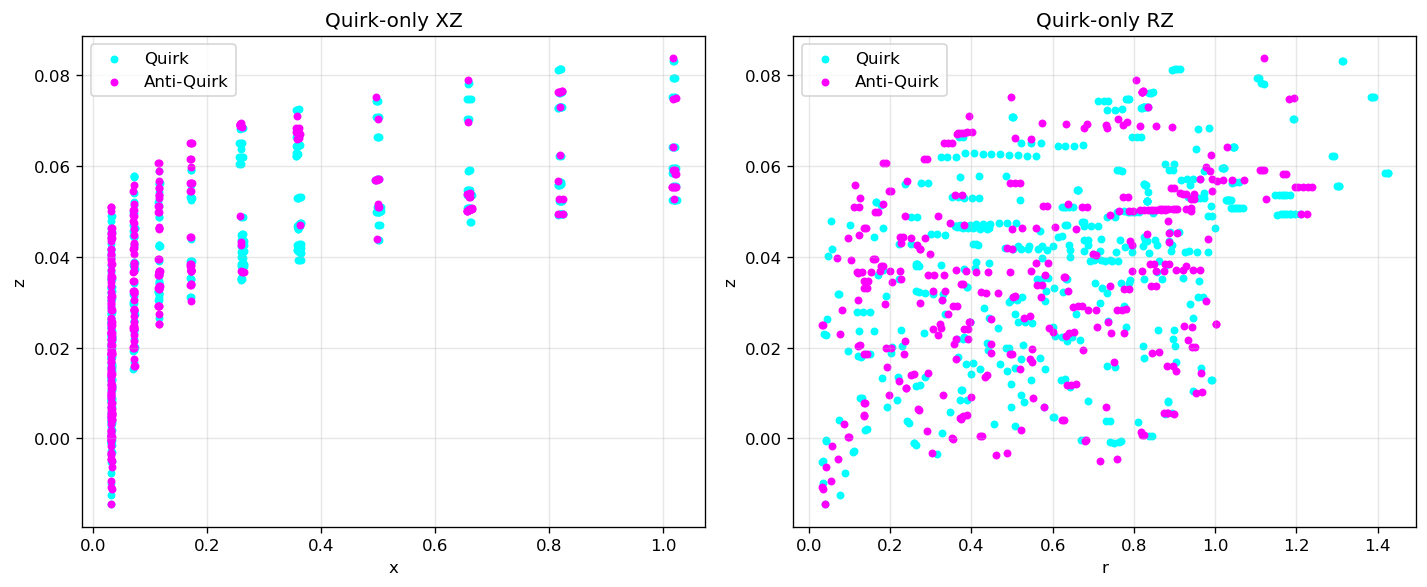

In [ ]:
r = np.sqrt(x**2 + y**2)

fig, ax = plt.subplots(1, 2, figsize=(12,5))

ax[0].scatter(x[q], z[q], s=14, c="cyan", label="Quirk")
ax[0].scatter(x[aq], z[aq], s=14, c="magenta", label="Anti-Quirk")
ax[0].set_xlabel("x"); ax[0].set_ylabel("z"); ax[0].set_title("Quirk-only XZ")
ax[0].grid(alpha=0.3); ax[0].legend()

ax[1].scatter(r[q], z[q], s=14, c="cyan", label="Quirk")
ax[1].scatter(r[aq], z[aq], s=14, c="magenta", label="Anti-Quirk")
ax[1].set_xlabel("r"); ax[1].set_ylabel("z"); ax[1].set_title("Quirk-only RZ")
ax[1].grid(alpha=0.3); ax[1].legend()

plt.tight_layout()
plt.show()


## Plot training metrics

We can examine how the training went. This is stored in a simple dataframe:

In [ ]:
embedding_metrics = get_training_metrics(metric_learning_trainer)
embedding_metrics.head()

In [ ]:
embedding_training_figs = plot_training_metrics(embedding_metrics)

## Evaluate model performance on sample test data

Here we evaluate the model performace on one sample test data. We look at how the efficiency and purity change with the embedding radius.

In [ ]:
neighbor_perf_figs = plot_neighbor_performance(metric_learning_model)

## Plot example truth and predicted graphs

In [ ]:
predicted_graph_figs = plot_predicted_graph(metric_learning_model)

## Track lengths

In [ ]:
track_length_figs = plot_track_lengths(metric_learning_model)

In [ ]:
graph_sizes_fig = plot_graph_sizes(metric_learning_model)

# 2. Construct graphs from metric learning inference

This step performs model inference on the entire input datasets (train, validation and test), to obtain input graphs to the graph neural network. Optionally, we also clear the directory.

In [ ]:
graph_builder = run_metric_learning_inference(CONFIG)

In [ ]:
import os, gc, torch

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    print(f"Cleared CUDA cache on {torch.cuda.get_device_name(0)}")
else:
    print("CUDA not available")

print("Run this cell right before Step 3. If allocator behavior is unchanged, restart kernel once.")


# 3. Train graph neural networks

We have a set of graphs constructed. We now train a GNN to classify edges as either "true" (belonging to the same track) or "false" (not belonging to the same track).

In [ ]:
gnn_trainer, gnn_model = train_gnn(CONFIG)

## Plot training metrics

In [ ]:
gnn_metrics = get_training_metrics(gnn_trainer)
gnn_metrics.head()

In [ ]:
gnn_training_figs = plot_training_metrics(gnn_metrics)

## Evaluate model performance on sample test data

Here we evaluate the model performace on one sample test data. We look at how the efficiency and purity change with the embedding radius.

In [ ]:
edge_perf_figs = plot_edge_performance(gnn_model)

# Step 4: GNN inference 

In [ ]:
run_gnn_inference(CONFIG)

# Step 5: Build track candidates from GNN

In [ ]:
build_track_candidates(CONFIG)

# Step 6: Evaluate track candidates

We can control the matching style in the pipeline config file. The following all require at least a majority of hits to match in each scheme (i.e. matching fraction = 50%).
A discussion of each matching style and some worked examples can be found in the [Documentation](https://hsf-reco-and-software-triggers.github.io/Tracking-ML-Exa.TrkX/performance/matching_definitions/).

ATLAS style matching is the default.

In [ ]:
evaluated_events, reconstructed_particles, particles, matched_tracks, tracks = evaluate_candidates(CONFIG)

In [ ]:
# Optional: save selected plots from this notebook
import os
from pathlib import Path

import matplotlib.pyplot as plt
from bokeh.io import export_png

SAVE_PLOTS = True  # Set True when you want to export
OUTPUT_DIR = Path("saved_plots")
MATPLOTLIB_DPI = 500
BOKEH_SCALE_FACTOR = 5

# Choose what to save
TO_SAVE = [
    "plot_true_graph",
    "embedding_training",
    "neighbor_performance",
    "predicted_graph",
    "track_lengths",
    "graph_sizes",
    "gnn_training",
    "edge_performance",
]

plot_registry = {
    "plot_true_graph": locals().get("plot_true_graph_fig"),
    "embedding_training": locals().get("embedding_training_figs"),
    "neighbor_performance": locals().get("neighbor_perf_figs"),
    "predicted_graph": locals().get("predicted_graph_figs"),
    "track_lengths": locals().get("track_length_figs"),
    "graph_sizes": locals().get("graph_sizes_fig"),
    "gnn_training": locals().get("gnn_training_figs"),
    "edge_performance": locals().get("edge_perf_figs"),
}

def _bokeh_figures(obj):
    if obj is None:
        return []
    if isinstance(obj, dict) and "figures" in obj:
        return obj["figures"]
    return [obj]

def _save_matplotlib(fig, outpath):
    fig.savefig(outpath, dpi=MATPLOTLIB_DPI, bbox_inches="tight")

def _save_bokeh(fig, outpath):
    # Requires selenium + browser driver for PNG export.
    export_png(fig, filename=str(outpath), scale_factor=BOKEH_SCALE_FACTOR)

if SAVE_PLOTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    saved, skipped, failed = [], [], []

    for name in TO_SAVE:
        obj = plot_registry.get(name)
        if obj is None:
            skipped.append((name, "plot object not found (run the source plotting cell first)"))
            continue

        if name == "graph_sizes":
            try:
                out = OUTPUT_DIR / f"{name}.png"
                _save_matplotlib(obj, out)
                saved.append(str(out))
            except Exception as exc:
                failed.append((name, str(exc)))
            continue

        figs = _bokeh_figures(obj)
        for idx, fig in enumerate(figs, start=1):
            suffix = f"_{idx}" if len(figs) > 1 else ""
            out = OUTPUT_DIR / f"{name}{suffix}.png"
            try:
                _save_bokeh(fig, out)
                saved.append(str(out))
            except Exception as exc:
                failed.append((f"{name}{suffix}", str(exc)))

    print(f"Saved {len(saved)} plot files")
    if saved:
        print("\n".join(saved))
    if skipped:
        print("\nSkipped:")
        for n, msg in skipped:
            print(f"- {n}: {msg}")
    if failed:
        print("\nFailed:")
        for n, msg in failed:
            print(f"- {n}: {msg}")
else:
    print("Set SAVE_PLOTS = True and rerun this cell to export selected plots.")

In [ ]:
print(plot_true_graph_fig if "plot_true_graph_fig" in locals() else "missing")
print(embedding_training_figs if "embedding_training_figs" in locals() else "missing")


In [ ]:
# Save notebook plots: Bokeh as individual HTML files, Matplotlib as PNG
from pathlib import Path

from bokeh.io import output_file, save
import matplotlib.pyplot as plt

SAVE_PLOTS = True
OUTPUT_DIR = Path("saved_plots")
MATPLOTLIB_DPI = 600

TO_SAVE = [
    "plot_true_graph",
    "embedding_training",
    "neighbor_performance",
    "predicted_graph",
    "track_lengths",
    "graph_sizes",
    "gnn_training",
    "edge_performance",
]

plot_registry = {
    "plot_true_graph": locals().get("plot_true_graph_fig"),
    "embedding_training": locals().get("embedding_training_figs"),
    "neighbor_performance": locals().get("neighbor_perf_figs"),
    "predicted_graph": locals().get("predicted_graph_figs"),
    "track_lengths": locals().get("track_length_figs"),
    "graph_sizes": locals().get("graph_sizes_fig"),
    "gnn_training": locals().get("gnn_training_figs"),
    "edge_performance": locals().get("edge_perf_figs"),
}

def _bokeh_figures(obj):
    if obj is None:
        return []
    if isinstance(obj, dict) and "figures" in obj:
        return obj["figures"]
    return [obj]

def _save_matplotlib(fig, outpath):
    fig.savefig(outpath, dpi=MATPLOTLIB_DPI, bbox_inches="tight")

def _save_bokeh_html(fig, outpath):
    output_file(str(outpath), title=outpath.stem)
    save(fig)

if SAVE_PLOTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    saved, skipped, failed = [], [], []

    for name in TO_SAVE:
        obj = plot_registry.get(name)
        if obj is None:
            skipped.append((name, "plot object not found (run the source plotting cell first)"))
            continue

        if name == "graph_sizes":
            try:
                out = OUTPUT_DIR / f"{name}.png"
                _save_matplotlib(obj, out)
                saved.append(str(out))
            except Exception as exc:
                failed.append((name, str(exc)))
            continue

        figs = _bokeh_figures(obj)
        for idx, fig in enumerate(figs, start=1):
            suffix = f"_{idx}" if len(figs) > 1 else ""
            out = OUTPUT_DIR / f"{name}{suffix}.html"
            try:
                _save_bokeh_html(fig, out)
                saved.append(str(out))
            except Exception as exc:
                failed.append((f"{name}{suffix}", str(exc)))

    print(f"Saved {len(saved)} plot files")
    if saved:
        print("\n".join(saved))
    if skipped:
        print("\nSkipped:")
        for n, msg in skipped:
            print(f"- {n}: {msg}")
    if failed:
        print("\nFailed:")
        for n, msg in failed:
            print(f"- {n}: {msg}")
else:
    print("Set SAVE_PLOTS = True and rerun this cell to export selected plots.")
